## 加载与切分数据（10s）

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_parquet('ecg_log_2026-02-25_095337.parquet')
window_size = 10 * 250
chunks = [data[i:i + window_size] for i in range(0, len(data), window_size)]

### nk.ecg_quality

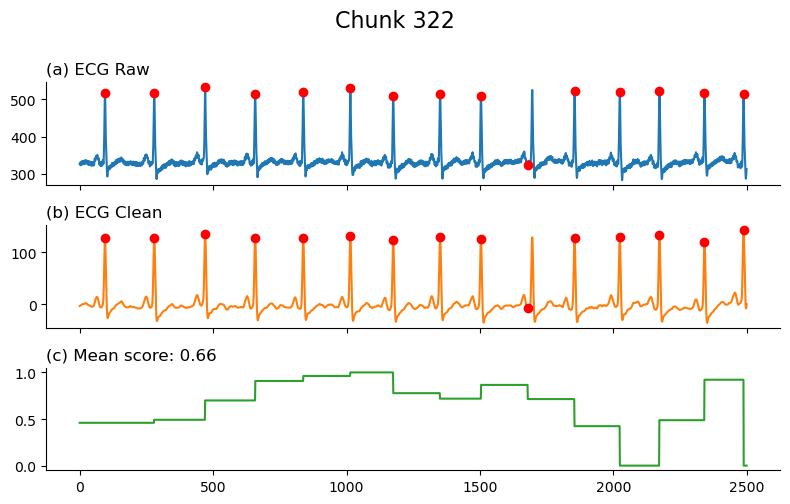

In [7]:
import neurokit2 as nk
idx = np.random.randint(len(chunks))
#idx = 150
idx=322
chunk = chunks[idx]
ecg_signals, info = nk.ecg_process(ecg_signal=chunk["ecg"], sampling_rate=250)

r_peak_idx = ecg_signals[ecg_signals['ECG_R_Peaks']!=0].index
r_hight_raw = ecg_signals.loc[r_peak_idx, 'ECG_Raw']
r_hight_clean = ecg_signals.loc[r_peak_idx, 'ECG_Clean']

fig, axes = plt.subplots(3, 1, figsize=(8, 5), sharex=True)
fig.subplots_adjust(hspace=0.4)
axes[0].plot(ecg_signals.index, ecg_signals['ECG_Raw'], c='C0', zorder=0)
axes[0].scatter(r_peak_idx, r_hight_raw, color='r', zorder=1)
axes[0].set_title('(a) ECG Raw', loc='left')

axes[1].plot(ecg_signals.index, ecg_signals['ECG_Clean'], c='C1', zorder=0)
axes[1].scatter(r_peak_idx, r_hight_clean, color='r', zorder=1)
axes[1].set_title('(b) ECG Clean', loc='left')

axes[2].plot(ecg_signals.index, ecg_signals['ECG_Quality'], c='C2')
axes[2].set_title(f"(c) Mean score: {np.mean(ecg_signals['ECG_Quality']):.2f}", loc='left')

fig.suptitle(
    f"Chunk {idx}", 
    y=1, fontsize=16
    )

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f"chunk{idx}.jpg", dpi=300)


## 标注（使用ecg_clean）
1. R-R 异常
2. 峰高异常
3. 基线异常


### 1. R-R 间隔

In [ ]:
"""
暂时借用 BeatCalc 类（不优雅也没关系！）
如果 rr_s 里有 nan，说明有峰被筛掉了。
一定是坏数据！所以测试完搞个函数。
"""

from rr_hr_hrv import *
chunk = chunk.copy()
ecg_signals, info = nk.ecg_process(ecg_signal=chunk["ecg"], sampling_rate=250)
ecg_clean = ecg_signals['ECG_Clean']
ecg_raw = ecg_signals['ECG_Raw']

nk_r_peaks = nk.ecg_findpeaks(ecg_clean, sampling_rate=250)['ECG_R_Peaks']
my_beats = BeatCalc(chunk)
my_rr_s, my_rr_clean = my_beats.get_clean_rr()
print(my_rr_s.hasnans)

True


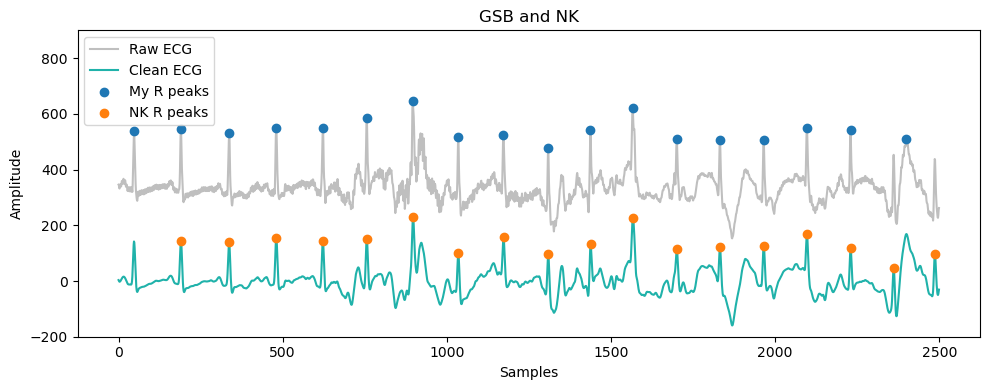

In [5]:
"""
总之画个图比较一下R峰识别方法！
我的R峰识别基于阈值，所以会误判基线漂移。
NK的R峰识别基于形态学，所以会漏掉不完整的心动周期。
"""

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

ax.plot(np.arange(2500), ecg_raw, color='gray', alpha=0.5, zorder=-1, label='Raw ECG')
ax.plot(np.arange(2500), ecg_clean, color='lightseagreen', zorder=-1, label='Clean ECG')
ax.scatter(my_beats.peaks, ecg_raw[my_beats.peaks], color='C0', label='My R peaks')
ax.scatter(nk_r_peaks, ecg_clean[nk_r_peaks], color='C1', label='NK R peaks')
ax.set_ylim(-200, 900)
ax.legend(loc='upper left')

ax.set_xlabel('Samples')
ax.set_ylabel('Amplitude')
ax.set_title('GSB and NK')
plt.tight_layout()

plt.savefig('r_gsb_nk.jpg', dpi=300)

## Bad 图例 5行

Text(0.5, 0, 'Time (s)')

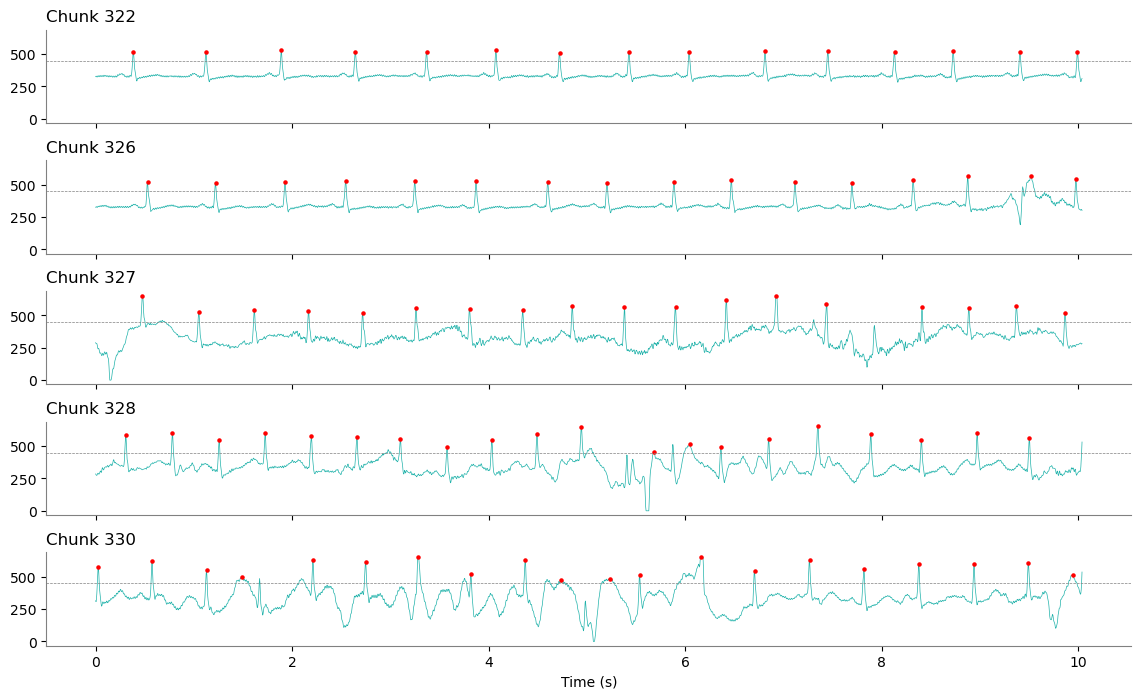

In [11]:
idxs = bad_idx[10:]

fig, axes = plt.subplots(5, 1, figsize=(14, 8), sharey=True, sharex=True)
fig.subplots_adjust(hspace=0.4)

for i in range(5):
    ax = axes[i]
    sample = chunks[idxs[i]].copy()
    sample['time'] -= sample['time'].iloc[0]
    beats_i = BeatCalc(sample)
    beat_idxs = beats_i.peaks

    ax.plot(
        sample['time'], sample['ecg'], 
        linewidth=0.5, zorder=-1,
        color='lightseagreen'
        )
    ax.scatter(
        sample.iloc[beat_idxs]['time'], 
        sample.iloc[beat_idxs]['ecg'], 
        color='red', zorder=1, s=5
    )
    ax.axhline(
        450, color='gray', 
        linewidth=0.5, 
        linestyle='--'
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('gray')
    ax.spines['left'].set_color('gray')
    ax.set_title(f"Chunk {idxs[i]}", loc='left')
axes[-1].set_xlabel('Time (s)')



In [12]:
beats = BeatCalc(chunks[322]) 
beats.rr_intervals

array([0.73597646, 0.76800108, 0.75199986, 0.7279985 , 0.704     ,
       0.64800024, 0.70399976, 0.61215258, 0.77601981, 0.63599968,
       0.67999983, 0.59600019, 0.67999983, 0.58399987])

In [17]:
np.diff(beats.rr_intervals)

array([ 0.03202462, -0.01600122, -0.02400136, -0.0239985 , -0.05599976,
        0.05599952, -0.09184718,  0.16386724, -0.14002013,  0.04400015,
       -0.08399963,  0.08399963, -0.09599996])